In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import emcee
from multiprocessing import Pool #Isso é para melhorar a utilização de processamento ao rodar o código MCMC.
                                 #Por algum motivo desconhecido atualmente, essa biblioteca não funciona bem neste computador
                                 #(e em alguns outros também).
import corner

In [15]:
#### Parametros do setor 1 ######
data=np.loadtxt('par_setor27_20s.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data[:,4]
x = np.log10(ener)
y = np.log10(dur)
erro =0.01*y 

In [16]:
def Reta(x, parametros):
    
    #ax + b
    a, b = parametros
    
    return a*x + b

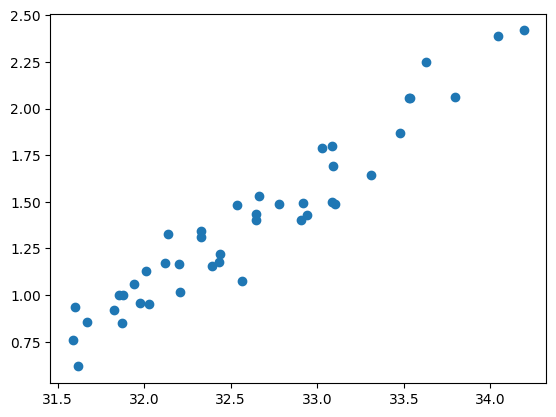

In [17]:
plt.plot(x,y,'o')

#plt.plot(x,Reta(x,[2,5]))

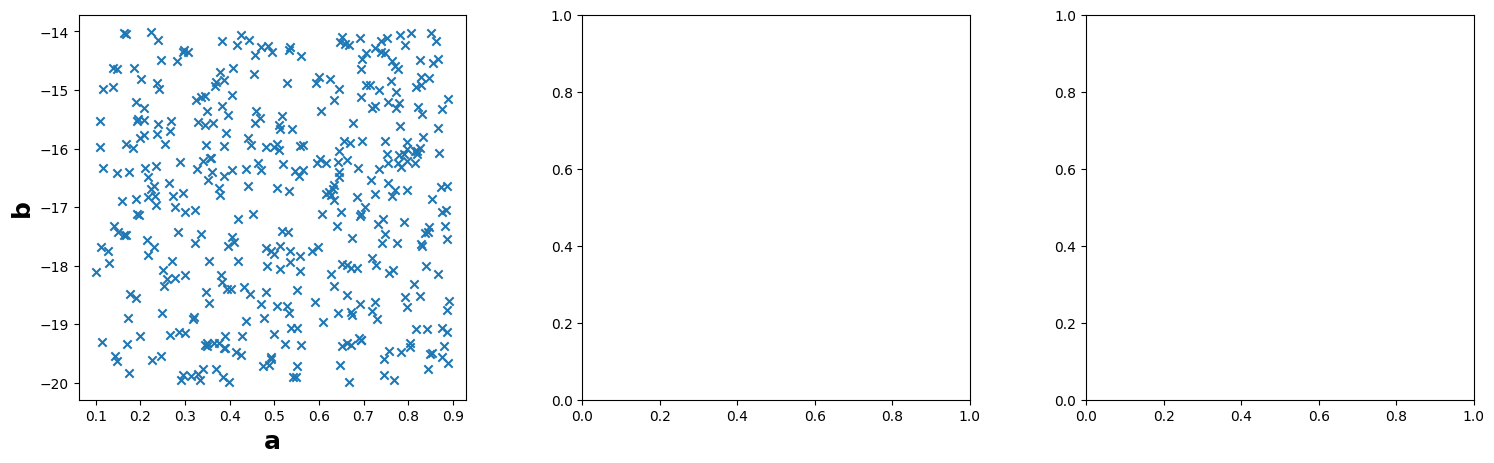

In [18]:
npar, nwalk, nstep = 2, 400, 600
#npar é o número de parâmetros.
#nwalk é número de algumas centenas. Varia de acordo com a quantidade de parâmetros.
#nstep é o número de passos. É precisso verificar se ele é bom.
#A cada passo, os nwalk vão caminhar um pouco, convergindo. Temos que ter passos o suficiente para que todos os walkers possam 
#caminhar.
#par0 é -3.8312,0.0794,-1.7

minw = np.array([0.1,-20])#0.3
#Mínimo de Ro, LxLbol, Rosat, LxLbolSat, Inclinacao

maxw = np.array([0.9,-14])#1.7
#Máximo de Ro, LxLbol, Rosat, LxLbolSat, Inclinacao

#.distribuindo walkers em torno dos valores iniciais (normal)
#wlk0 = par0 + 0.25*std0*np.random.randn(nwalk,npar)
wlk0 = minw + (maxw-minw)*np.random.rand(nwalk,npar)
#.aplicando os limites maximo e minimo
wlk0.clip(min=minw, max=maxw, out=wlk0)

#.visualizando distribuicao inicial walkers
#fig = plt.figure(figsize=(5,5))
#plt.subplots_adjust(wspace=0.3)

#plt.scatter(wlk0[:,0], wlk0[:,1], marker='x')
#plt.ylabel('Ro', fontweight='bold', fontsize=18)
#plt.xlabel('LxLbol', fontweight='bold', fontsize=18)
#plt.ylim((max(Ro), min(Ro)))
#plt.xlim((min(LxLbol), max(LxLbol)))


#.visualizando distribuicao inicial walkers
fig, [ax1, ax2, ax3] = plt.subplots(1,3,figsize=(18,5))
plt.subplots_adjust(wspace=0.3)

ax1.scatter(wlk0[:,0], wlk0[:,1], marker='x')
ax1.set_ylabel('b', fontweight='bold', fontsize=18)
ax1.set_xlabel('a', fontweight='bold', fontsize=18)

#ax2.scatter(wlk0[:,0], wlk0[:,2], marker='x')
#ax2.set_xlabel('LxLbol', fontweight='bold', fontsize=18)
#ax2.set_ylabel(r'$\beta$', fontweight='bold', fontsize=18);

#ax3.scatter(wlk0[:,1], wlk0[:,2], marker='x')
#ax3.set_xlabel('Ro', fontweight='bold', fontsize=18)
#ax3.set_ylabel(r'$\beta$', fontweight='bold', fontsize=18);

fig.savefig('EspacoParametros.png', dpi = 400)

In [19]:
def loglike( walker ):
    #Tem que pegar uma tentativa de parametro e retornar um numero que informa quao bom esta o ponto do modelo.
    #Uma estrela muito próxima do modelo ganha um alto likehood. Se estiver longe, ganha um pequeno.
    
#    center = SkyCoord(walker[0]*units.degree, walker[1]*units.degree, frame='fk5')
#    rad = center.separation(catalog).to(units.arcsec).value #Pega só o valor, em arcsec
    
    model = Reta(x, walker) #Pega apenas os dois primeiros, que é o centro.
    
    chi = (y-model)/(erro) #Esse é o log(L)
    return -0.5*chi**2 #E estou retornando o chi, ou seja, o log.
                       #Repare que aqui não tem a soma, é para cada estrela, individualmente.

def logprior( walker ):
    
    good_par = (walker > minw) & (walker < maxw)
    if np.all(good_par): 
        # return -0.5*(((par0-walker)/std0)**2)
        return np.zeros(npar)
    else: return -np.inf

def logpost( walker ):
    prior = np.sum(logprior(walker))
    if np.isfinite(prior):
        return prior + np.sum(loglike(walker)) #É um artifício que se utiliza para não calcular coisas desnecessárias.
    else: return -np.inf


In [20]:
#with Pool() as pool:
sampler = emcee.EnsembleSampler( nwalk, npar, logpost)#, pool=pool )
#            moves=[(emcee.moves.DEMove(), 0.8), (emcee.moves.StretchMove(), 0.2)] )
sampler.run_mcmc(wlk0, nstep, progress=True)

100%|█████████████████████████████████████████| 600/600 [00:07<00:00, 79.47it/s]


State([[  0.59918276 -18.16972066]
 [  0.59465323 -18.02533573]
 [  0.59860212 -18.15514531]
 [  0.59809377 -18.13722917]
 [  0.60128515 -18.23840277]
 [  0.59797711 -18.13483373]
 [  0.59943805 -18.1786668 ]
 [  0.59829642 -18.14304268]
 [  0.60084473 -18.22565728]
 [  0.59849552 -18.14844705]
 [  0.59624344 -18.07911521]
 [  0.5974524  -18.11931068]
 [  0.60147787 -18.24326676]
 [  0.60108305 -18.23361519]
 [  0.60508938 -18.36344178]
 [  0.60011968 -18.20065299]
 [  0.60052711 -18.21513947]
 [  0.5978615  -18.12524758]
 [  0.59787903 -18.12778354]
 [  0.60009218 -18.20076414]
 [  0.59876163 -18.15805577]
 [  0.60121694 -18.23377931]
 [  0.59762823 -18.12110192]
 [  0.60489114 -18.35565132]
 [  0.60673547 -18.41345142]
 [  0.5921944  -17.94800281]
 [  0.59906947 -18.16866372]
 [  0.59806805 -18.13411029]
 [  0.60269445 -18.28625174]
 [  0.59835893 -18.14564243]
 [  0.59993885 -18.19402164]
 [  0.59700137 -18.10132831]
 [  0.60030402 -18.20682329]
 [  0.60105303 -18.23243562]
 [  0.60

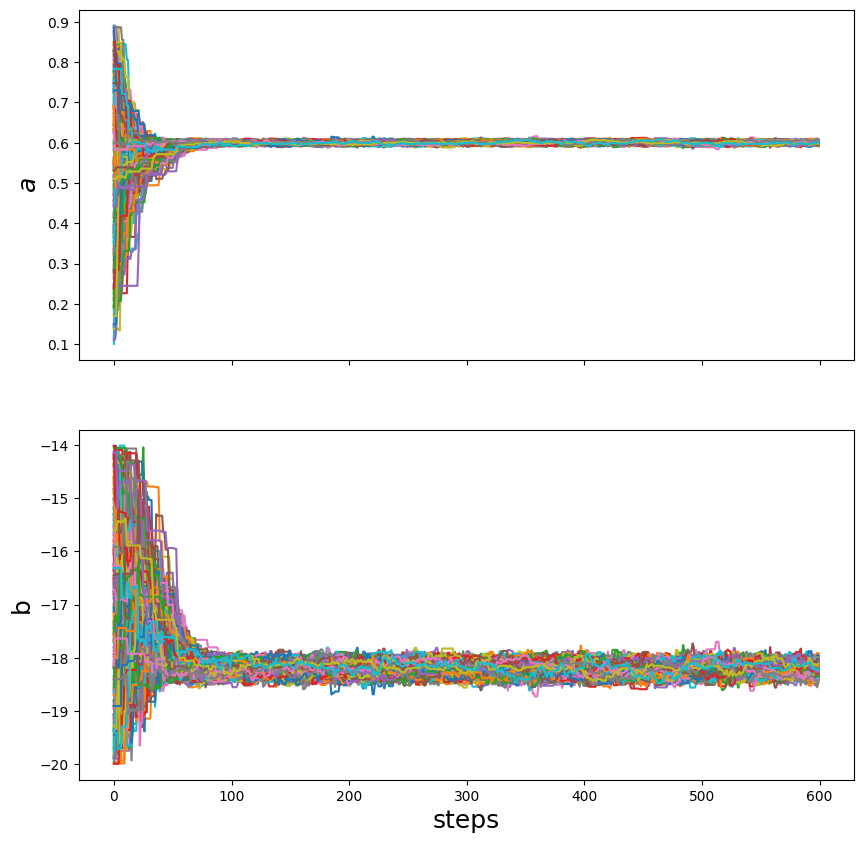

In [21]:
#..labels e unidades dos parametros
labels = [r"$a$", r"b"]
#units = ["deg", "deg", "arcsec$^{-2}$", "arcsec", "arcsec", "arcsec$^{-2}$"]

#.construindo o tracer plot
fig, axes = plt.subplots(npar, 1, sharex=True, figsize=(10,10) )
for i in range(npar):
    axes[i].plot(np.array(sampler.chain[:,:,i]).T,rasterized=True)
    axes[i].set_ylabel(labels[i], fontsize=18)
axes[npar-1].set_xlabel(r'steps', fontsize=18)

fig.savefig('Steps.png', dpi = 400)

In [22]:
#..obtendo tempo de correlaçao dos parametros
tau = sampler.get_autocorr_time(tol=0)
#print(tau)
#Diz quanto tempo leva para que os parâmetros cheguem a convergir.

#..determinando estados iniciais (burn-in) e estados correlacionados (thinning)
burnin = int(2 * np.max(tau)) #Número de estados iniciais que você pode descartar, porque aí ficaremos livres das escolhas 
                              #iniciais.
thin = int(0.5 * np.min(tau)) #

#print(burnin,thin)

#..obtendo taxa de aceitação dos walkers
acc = sampler.acceptance_fraction
#Um bom walker fica entre 20% e 50%
print(acc)

#..determinando walkers "perdidos"
good_walker = (abs(acc-np.median(acc)) < 3*np.std(acc))

#..selecionando apenas estados estacionarios não correlacionados
states = sampler.chain[good_walker,burnin::thin,:].copy() #faz uma seleção em [200,1000,6]
#print(np.shape(states))

#..redimensionando a cadeia
nwlk, nthin, _ = np.shape(states)
states = np.reshape(states,[nwlk*nthin, npar])
#Aqui fiz um vetor redimensionado, com 6 colunas
#print(np.shape(states))

#.obtendo valores mais provaveis dos parametros
quantiles = np.quantile(states,[0.16,0.50,0.84],axis=0)

pars_best = quantiles[1,:]
perr_low  = quantiles[0,:]-pars_best
perr_high = quantiles[2,:]-pars_best

print(pars_best)
print(perr_low)
print(perr_high)


[0.68333333 0.675      0.67833333 0.66666667 0.69666667 0.69666667
 0.68166667 0.66833333 0.7        0.65333333 0.64       0.71166667
 0.68666667 0.69666667 0.63333333 0.7        0.69333333 0.69166667
 0.68       0.715      0.725      0.68666667 0.66333333 0.66833333
 0.70333333 0.705      0.63666667 0.67666667 0.65666667 0.68
 0.7        0.645      0.7        0.69166667 0.69166667 0.67666667
 0.71       0.675      0.64833333 0.67666667 0.645      0.665
 0.67666667 0.715      0.655      0.69       0.63333333 0.7
 0.70833333 0.72833333 0.685      0.65166667 0.66833333 0.69166667
 0.685      0.72666667 0.69333333 0.68       0.65       0.66833333
 0.65       0.69166667 0.72       0.66333333 0.69333333 0.70666667
 0.67833333 0.70833333 0.675      0.65       0.64833333 0.68
 0.7        0.66       0.67       0.71       0.70166667 0.66666667
 0.67333333 0.69333333 0.68333333 0.69166667 0.69333333 0.675
 0.67833333 0.67166667 0.67333333 0.67166667 0.71       0.67
 0.66666667 0.68166667 0.67166

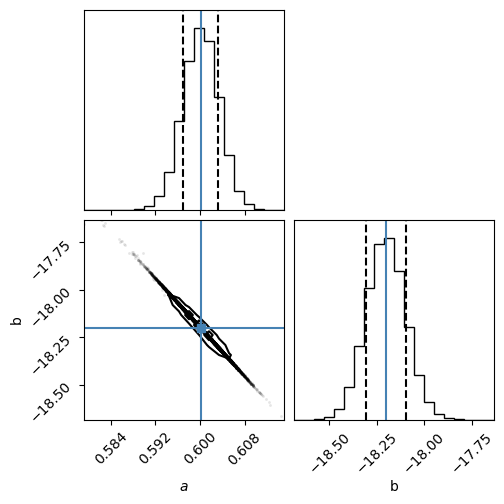

In [23]:
#.corner plot
fig = corner.corner(states, labels=labels, truths=pars_best, \
 quantiles=[0.16,0.84], scale_hist=False, hist_bins='scott', density=True,\
 plot_density=False, plot_contours=True, no_fill_contours=True, \
 hist2d_plot_datapoints=True, hist2d_data_alpha=0.75)#,
#                   show_titles=True)

#A parte abaixo é uma forma de tentar escrever as legendas da figura corner. É preciso ir rodando e testando para ver como
#funciona, mas consiste em andar por cada quadrante do plot (que é 3x3, sendo 3 o número de gráficos/quadrantes, apesar de
#alguns estarem vazios - o que dá o formato "triangular" à figura).

#c = 0
#l=0
#ly = 1
#lsize = 20
#lsize2 = 20

#for ax in fig.get_axes():
#    ax.tick_params(axis='both', labelsize=lsize-5.5)
    
#    if c == 0:
#        ax.set_title(resultadosl[0], fontsize = lsize2)
#    if c == 4:
#        ax.set_title(resultadosl[1], fontsize = lsize2)
#    if c == 8:
#        ax.set_title(resultadosl[2], fontsize = lsize2)
#        
#    if  c - 3 == 0 or c - 6 == 0:
#        ax.set_ylabel(labels[ly],fontsize = lsize)
#        ly+=1
#    if c>5:
#        ax.set_xlabel(labels[l],fontsize = lsize)
#        l+=1
#    c+=1

fig.savefig('FiguraCorner.png', dpi = 400)

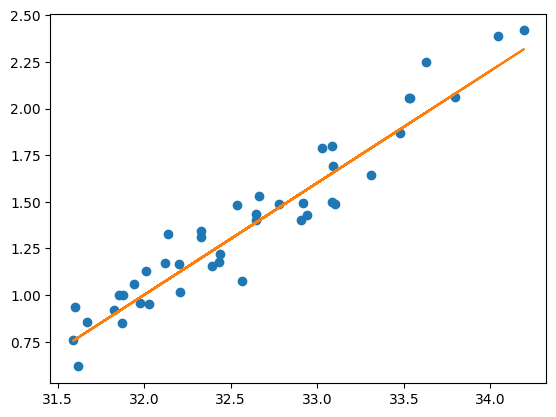

In [25]:
plt.plot(x,y,'o')
plt.plot(x,Reta(x,pars_best))
plt.show()